# Vyorius Drone Operations Analytics
**Goal:** turn mission, telemetry, maintenance, customer and financial data into operational KPIs, root-cause insights and AI-assisted decision support.

> Portfolio note: the dataset is synthetic. “MRR Proxy” means monthly mission revenue, because invoice-level subscription billing is not present.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../data/raw/vyorius_drone_operations_synthetic_2021_2026.csv")
df = pd.read_csv(DATA, parse_dates=["mission_date"])
df.shape

(15000, 62)

## 1. Data quality and structure

In [2]:
print(df.info())
display((df.isna().mean()*100).sort_values(ascending=False).head(12).to_frame("missing_%"))
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 62 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   mission_id                     15000 non-null  object        
 1   mission_date                   15000 non-null  datetime64[ns]
 2   mission_start_time             15000 non-null  object        
 3   year                           15000 non-null  int64         
 4   quarter                        15000 non-null  object        
 5   month                          15000 non-null  object        
 6   customer_id                    15000 non-null  object        
 7   customer_industry              15000 non-null  object        
 8   subscription_plan              15000 non-null  object        
 9   city                           15000 non-null  object        
 10  state                          15000 non-null  object        
 11  latitude       

,missing_%
failure_reason,83.766667
customer_rating,0.673333
mission_start_time,0.000000
year,0.000000
mission_id,0.000000
mission_date,0.000000
customer_id,0.000000
customer_industry,0.000000
subscription_plan,0.000000
city,0.000000


,mission_id,mission_date,mission_start_time,year,quarter,month,customer_id,customer_industry,subscription_plan,city,state,latitude,longitude,drone_id,manufacturer,drone_model,platform_type,vehicle_type,autopilot_stack,firmware_channel,mission_type,mission_distance_km,mission_duration_min,average_speed_mps,payload_kg,max_payload_capacity_kg,payload_utilization_pct,battery_start_pct,battery_end_pct,battery_consumed_pct,battery_health_pct,charge_cycles,max_reference_flight_time_min,max_reference_speed_mps,wind_speed_mps,temperature_c,weather_condition,gps_satellites,gps_accuracy_m,signal_strength_pct,rtk_supported,rtk_used,thermal_supported,sensor_used,mission_status,failure_reason,delay_minutes,emergency_landing,operator_id,operator_experience_years,manual_interventions,maintenance_due,days_since_last_service,downtime_hours,maintenance_cost_inr,revenue_inr,estimated_operating_cost_inr,gross_margin_inr,customer_rating,data_record_type,data_quality_note,public_spec_source_url
0,MSN-2026-000001,2026-06-10,15:07:05,2026,Q2,Jun,CUST-1099,Agriculture,Professional,Indore,Madhya Pradesh,22.797348,76.030259,DRN-0172,DJI,Mavic 3 Enterprise,Commercial Enterprise Drone,Multirotor,DJI Proprietary,Stable,Crop Health Survey,11.80,19.43,10.12,0.01,0.2,3.04,86.36,53.79,32.57,94.92,164,45,21.0,5.28,24.48,Light Rain,25,1.15,94.60,Yes,No,No,RGB,Completed,NaN,0,No,OP-212,4.8,2,Yes,96,2.7,1719.40,7387.49,1165.63,6221.86,4.4,Synthetic mission record with public specifica...,Not internal Vyorius data. Drone specification...,https://enterprise.dji.com/mavic-3-enterprise/...
1,MSN-2022-000002,2022-12-10,01:19:36,2022,Q4,Dec,CUST-1299,Telecom,Enterprise Plus,Delhi,Delhi,28.593401,77.356009,DRN-0509,Custom,ArduPilot Agro Hexa,Custom Drone,Multirotor,ArduPilot,Long-Term Support,Tower Inspection,6.37,14.86,7.15,0.57,10.0,5.69,83.89,54.72,29.17,99.73,62,35,15.0,3.52,21.92,Clear,32,1.60,80.81,Optional,Yes,No,RGB,Completed,NaN,0,No,OP-293,3.7,1,Yes,117,4.0,1525.93,19921.01,997.44,18923.57,4.6,Synthetic mission record with public specifica...,Not internal Vyorius data. Drone specification...,https://ardupilot.org/ardupilot/
2,MSN-2022-000003,2022-11-13,09:44:27,2022,Q4,Nov,CUST-1166,Public Safety,Starter,Mumbai,Maharashtra,18.904246,72.933776,DRN-0601,Custom,ArduPilot Long-Range VTOL,Custom Drone,VTOL,ArduPilot,Long-Term Support,Perimeter Surveillance,41.46,53.96,12.81,0.83,3.0,27.72,93.83,49.10,44.73,89.81,450,120,32.0,0.79,18.18,Clear,19,0.99,63.85,Yes,No,Optional,RGB,Completed,NaN,0,No,OP-205,4.6,0,Yes,95,17.0,2029.62,4454.04,2430.52,2023.52,4.6,Synthetic mission record with public specifica...,Not internal Vyorius data. Drone specification...,https://ardupilot.org/ardupilot/docs/common-al...
3,MSN-2021-000004,2021-12-14,13:27:43,2021,Q4,Dec,CUST-1110,Energy & Utilities,Professional,Pune,Maharashtra,18.335053,73.958739,DRN-0653,Custom,ArduPilot Long-Range VTOL,Custom Drone,VTOL,ArduPilot,Long-Term Support,Solar Farm Inspection,89.05,92.09,16.12,0.86,3.0,28.56,82.94,14.75,68.19,84.23,387,120,32.0,1.75,30.47,Cloudy,32,1.06,85.38,Yes,Yes,Optional,Thermal,Completed,NaN,0,No,OP-234,1.0,0,No,8,0.0,0.00,12665.18,5055.07,7610.11,4.5,Synthetic mission record with public specifica...,Not internal Vyorius data. Drone specification...,https://ardupilot.org/ardupilot/docs/common-al...
4,MSN-2025-000005,2025-11-10,04:03:33,2025,Q4,Nov,CUST-1002,Telecom,Enterprise,Hyderabad,Telangana,17.207650,78.456363,DRN-0500,Custom,PX4 Surveyor X8,Custom Drone,Multirotor,PX4,Long-Term Support,Network Site Survey,10.57,21.75,8.10,0.30,2.0,14.83,79.11,39.26,39.85,98.49,82,48,18.0,3.78,31.79,Clear,14,1.75,97.94,Yes,No,Optional,RGB,Completed,NaN,0,No,OP-268,1.8,0,No,54,0.0,0.00,14086.48,939.09,13147.39,4.2,Synthetic mission record with public specifica...,Not internal Vyorius data. Drone specification...,https://docs.px4.io/main/en/


## 2. Executive KPIs

In [3]:
kpi = {
"Total Missions": len(df),
"Unique Drones": df.drone_id.nunique(),
"Unique Customers": df.customer_id.nunique(),
"Success Rate %": 100*(df.mission_status=="Completed").mean(),
"Delay Rate %": 100*(df.mission_status=="Delayed").mean(),
"Failure Rate %": 100*(df.mission_status=="Failed").mean(),
"Average Battery Health %": df.battery_health_pct.mean(),
"Revenue INR": df.revenue_inr.sum(),
"Gross Margin %": 100*df.gross_margin_inr.sum()/df.revenue_inr.sum()
}
pd.Series(kpi).to_frame("value")

,value
Total Missions,1.500000e+04
Unique Drones,6.800000e+02
Unique Customers,4.500000e+02
Success Rate %,8.376667e+01
Delay Rate %,1.413333e+01
Failure Rate %,1.426667e+00
Average Battery Health %,8.958711e+01
Revenue INR,1.769738e+08
Gross Margin %,8.701816e+01


## 3. Monthly trends

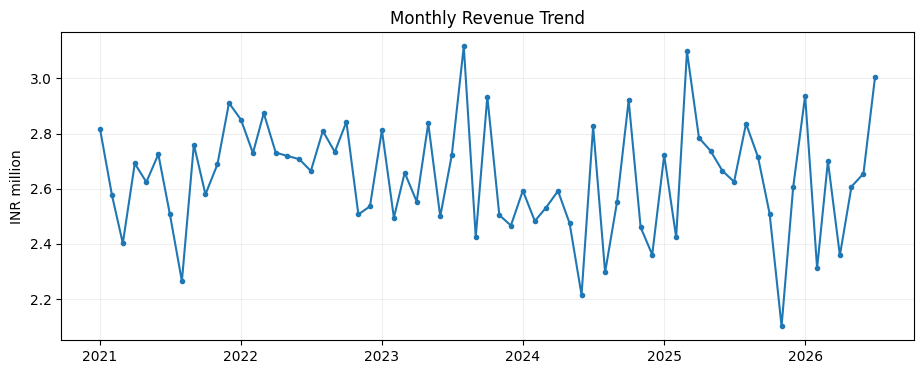

,month,missions,revenue,success_rate,month_dt
62,2026-03,218,2699699.68,81.651376,2026-03-01
63,2026-04,201,2358176.93,86.069652,2026-04-01
64,2026-05,216,2607556.84,85.185185,2026-05-01
65,2026-06,216,2654594.69,87.037037,2026-06-01
66,2026-07,244,3005110.81,81.967213,2026-07-01


In [4]:
df["month"]=df.mission_date.dt.to_period("M").astype(str)
monthly=df.groupby("month").agg(
    missions=("mission_id","count"),
    revenue=("revenue_inr","sum"),
    success_rate=("mission_status",lambda s:100*(s=="Completed").mean())
).reset_index()
monthly["month_dt"]=pd.to_datetime(monthly["month"])
plt.figure(figsize=(11,4))
plt.plot(monthly.month_dt,monthly.revenue/1e6,marker="o",markersize=3)
plt.title("Monthly Revenue Trend")
plt.ylabel("INR million")
plt.grid(alpha=.2)
plt.show()
monthly.tail()

## 4. Reliability by manufacturer

,missions,success_rate,battery_health,downtime,maintenance_cost
manufacturer,,,,,
DJI,4065,84.354244,89.551250,15726.4,3036756.65
Custom,6394,83.562715,89.577158,25052.6,4832854.26
Parrot,1950,83.538462,89.487544,7884.4,1524023.91
Autel,2591,83.519876,89.742868,10641.1,2089909.33


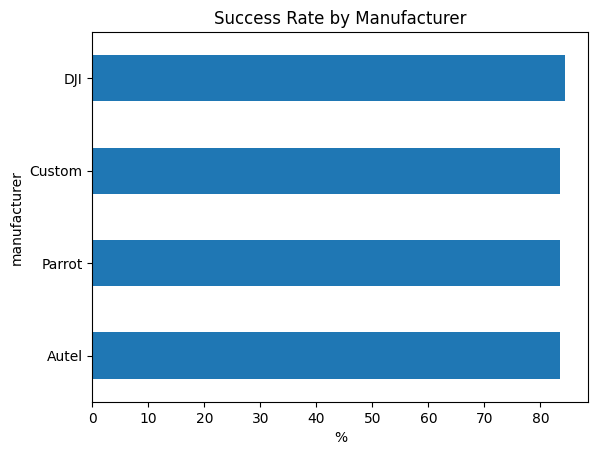

In [5]:
vendor=df.groupby("manufacturer").agg(
    missions=("mission_id","count"),
    success_rate=("mission_status",lambda s:100*(s=="Completed").mean()),
    battery_health=("battery_health_pct","mean"),
    downtime=("downtime_hours","sum"),
    maintenance_cost=("maintenance_cost_inr","sum")
).sort_values("success_rate",ascending=False)
display(vendor)
vendor.success_rate.sort_values().plot(kind="barh",title="Success Rate by Manufacturer")
plt.xlabel("%")
plt.show()

## 5. Root-cause analysis

,mission_status,failure_reason,events
1,Delayed,Battery Swap,546
3,Delayed,Weather Hold,535
2,Delayed,Operator Queue,524
0,Delayed,Airspace Approval,515
5,Failed,GPS Degradation,88
7,Failed,High Wind,42
8,Failed,Low Battery,23
9,Failed,Motor Alert,15
10,Failed,Payload Imbalance,15
4,Failed,Communication Loss,12


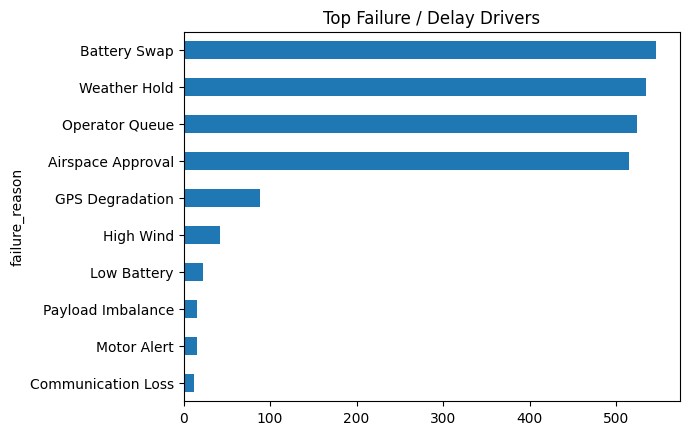

In [6]:
drivers=(df[df.mission_status.isin(["Failed","Delayed"])]
         .groupby(["mission_status","failure_reason"]).size()
         .reset_index(name="events").sort_values("events",ascending=False))
display(drivers.head(12))
drivers.head(10).sort_values("events").plot(
    kind="barh",x="failure_reason",y="events",legend=False,title="Top Failure / Delay Drivers")
plt.show()

## 6. Commercial analytics

In [7]:
industry=df.groupby("customer_industry").agg(
    missions=("mission_id","count"),
    revenue=("revenue_inr","sum"),
    margin=("gross_margin_inr","sum"),
    rating=("customer_rating","mean")
)
industry["margin_pct"]=100*industry["margin"]/industry["revenue"]
display(industry.sort_values("revenue",ascending=False))

,missions,revenue,margin,rating,margin_pct
customer_industry,,,,,
Mining,2201,30448244.77,27059833.05,4.382784,88.871570
Energy & Utilities,2058,29774605.70,26648271.77,4.391096,89.499999
Public Safety,2173,28406743.34,25158446.38,4.372222,88.565050
Infrastructure Inspection,2197,24582604.39,21227070.93,4.373559,86.349968
Telecom,2145,23965280.50,20714163.83,4.377017,86.434055
Agriculture,2136,21495196.07,18264911.42,4.376518,84.972062
Logistics,2090,18301170.85,14926681.75,4.359913,81.561349


## 7. AI decision-support concept

The project uses AI in two transparent ways:
1. **Predictive maintenance prototype** — classify whether maintenance is due from pre-maintenance signals.
2. **AI-assisted scheduling** — score mission readiness using wind, battery, signal, GPS, payload and maintenance risk; low-risk missions are scheduled first, medium-risk missions are reviewed, and high-risk missions are deferred/reassigned.

This is a decision-support prototype, not autonomous flight control.

In [8]:
print("Predictive-maintenance POC ROC-AUC: 0.987")
print("Predictive-maintenance POC accuracy: 0.990")
display(pd.read_csv("../data/processed/predictive_maintenance_feature_importance.csv").head(10))

Predictive-maintenance POC ROC-AUC: 0.987
Predictive-maintenance POC accuracy: 0.990


,base_feature,importance
0,days_since_last_service,0.941799
1,battery_health_pct,0.014161
2,mission_duration_min,0.010517
3,payload_utilization_pct,0.009976
4,mission_distance_km,0.009840
5,charge_cycles,0.009615
6,drone_model,0.002682
7,manufacturer,0.001073
8,platform_type,0.000336


## 8. Management recommendations

- Prioritize GPS degradation and high-wind mitigation because they are the leading observed failed-mission causes.
- Use maintenance-risk scoring to pull high-risk drones into service before failure.
- Add scheduling constraints that avoid high-wind / weak-signal combinations and reassign missions to healthier aircraft.
- Use the fleet scorecard to shift work from overburdened to underutilized drones.
- Standardize telemetry fields across DJI, Autel, Parrot, PX4 and ArduPilot for a vendor-agnostic operations layer.
- Treat autonomous mission planning as a phased roadmap: decision support → human-approved routing → controlled autonomy.